# Notebook 03 — IV vs Realised Volatility

This notebook moves from theory to real data.

**Realised Volatility (RV)** — what volatility actually was, measured from historical prices.  
**Implied Volatility (IV)** — what volatility the options market *expects*, embedded in option prices.

The gap between IV and RV is called the **volatility risk premium (VRP)**.  
If IV > RV consistently, selling options is structurally profitable — this is the thesis behind our backtest.

Data sources:
- **NIFTY spot prices** → yfinance (`^NSEI`)
- **India VIX** → yfinance (`^INDIAVIX`) — NSE's official NIFTY implied volatility index

Topics:
1. Download and explore the data
2. Three RV estimators: Close-to-Close, Parkinson, Yang-Zhang
3. IV vs RV chart and the volatility risk premium
4. Regime analysis — when does IV > RV and by how much?
5. Brief demo of the NSE bhavcopy data loader

In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

from volatility import (
    close_to_close_rv,
    parkinson_rv,
    yang_zhang_rv,
    iv_rv_summary,
)

print("Imports OK")

Imports OK


---
## 1. Download data

We download 3 years of daily OHLC data for NIFTY and India VIX.

**India VIX** is computed by NSE using the same methodology as the CBOE VIX.
It represents the market's expectation of 30-day annualised volatility for NIFTY.
It is not a proxy — it is the actual implied volatility surface of NIFTY options condensed into one number.

In [3]:
# Download NIFTY spot (OHLC) and India VIX
START = "2021-01-01"
END   = "2024-12-31"

print("Downloading NIFTY data...")
nifty_raw = yf.download("^NSEI", start=START, end=END, auto_adjust=True, progress=False)

print("Downloading India VIX data...")
vix_raw = yf.download("^INDIAVIX", start=START, end=END, auto_adjust=True, progress=False)

print(f"\nNIFTY  : {len(nifty_raw)} trading days  ({nifty_raw.index[0].date()} to {nifty_raw.index[-1].date()})")
print(f"VIX    : {len(vix_raw)} trading days  ({vix_raw.index[0].date()} to {vix_raw.index[-1].date()})")
print()
print(nifty_raw.tail(3))


NIFTY  : 986 trading days  (2021-01-01 to 2024-12-30)
VIX    : 973 trading days  (2021-01-04 to 2024-12-30)

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2024-12-26  23750.199219  23854.500000  23653.599609  23775.800781  177700
2024-12-27  23813.400391  23938.849609  23800.599609  23801.400391  176800
2024-12-30  23644.900391  23915.349609  23599.300781  23796.900391  364900


In [4]:
# Clean up columns (yfinance sometimes returns MultiIndex)
if isinstance(nifty_raw.columns, pd.MultiIndex):
    nifty_raw.columns = nifty_raw.columns.get_level_values(0)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)

# Extract what we need
nifty = nifty_raw[["Open", "High", "Low", "Close"]].copy()
nifty.columns = ["open", "high", "low", "close"]
nifty = nifty.dropna()

# India VIX is in percentage points — convert to decimal
vix = (vix_raw["Close"] / 100).rename("india_vix").dropna()

print("NIFTY columns:", nifty.columns.tolist())
print("NIFTY rows after cleaning:", len(nifty))
print(f"VIX range: {vix.min():.2%} to {vix.max():.2%}")
print(f"VIX current: {vix.iloc[-1]:.2%}")

NIFTY columns: ['open', 'high', 'low', 'close']
NIFTY rows after cleaning: 986
VIX range: 10.14% to 31.98%
VIX current: 13.97%


Saved to data/processed/


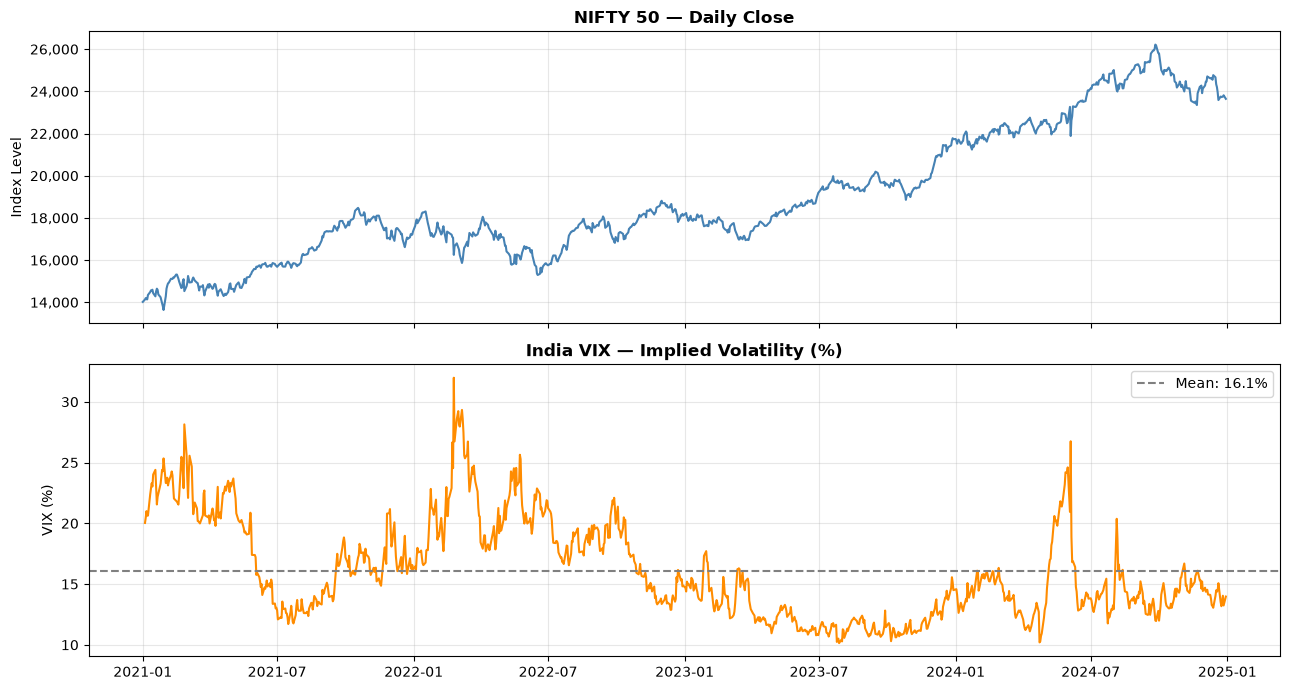

In [5]:
# Save to processed folder for use in later notebooks
nifty.to_csv("../data/processed/nifty_spot.csv")
vix.to_csv("../data/processed/india_vix.csv")
print("Saved to data/processed/")

# Quick chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(nifty.index, nifty["close"], color="steelblue", lw=1.5)
ax1.set_title("NIFTY 50 — Daily Close", fontweight="bold")
ax1.set_ylabel("Index Level")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.grid(alpha=0.3)

ax2.plot(vix.index, vix * 100, color="darkorange", lw=1.5)
ax2.axhline(vix.mean() * 100, color="gray", ls="--", label=f"Mean: {vix.mean():.1%}")
ax2.set_title("India VIX — Implied Volatility (%)", fontweight="bold")
ax2.set_ylabel("VIX (%)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 2. Realised Volatility — three estimators

We compute RV using three methods, each using more price information than the last.

### Close-to-Close
Standard method. Uses only daily closing prices.
```
sigma = std(log returns) * sqrt(252)
```
Simple but ignores intraday moves and overnight gaps.

### Parkinson (1980)
Uses high-low range. More efficient under Geometric Brownian Motion assumptions.
```
sigma^2 = (1 / 4*ln2) * E[(ln H/L)^2]
```
About 5x more efficient than close-to-close when there are no overnight gaps.

### Yang-Zhang (2000)
Uses full OHLC. Most accurate standard estimator.
Combines overnight, open-to-close, and Rogers-Satchell components.

In [6]:
RV_WINDOW = 20  # 20 trading days ~ 1 month

rv_ctc  = close_to_close_rv(nifty["close"], RV_WINDOW)
rv_park = parkinson_rv(nifty["high"], nifty["low"], RV_WINDOW)
rv_yz   = yang_zhang_rv(nifty["open"], nifty["high"], nifty["low"], nifty["close"], RV_WINDOW)

# Summary stats
rv_df = pd.DataFrame({"Close-to-Close": rv_ctc, "Parkinson": rv_park, "Yang-Zhang": rv_yz}).dropna()

print("RV Summary Statistics (annualised %)")
print("=" * 50)
print((rv_df * 100).describe().round(2).to_string())

RV Summary Statistics (annualised %)
       Close-to-Close  Parkinson  Yang-Zhang
count          966.00     966.00      966.00
mean            13.53      11.07       13.66
std              5.51       3.47        4.49
min              5.02       5.64        6.39
25%              9.51       8.40       10.32
50%             11.72      10.44       12.51
75%             16.22      12.89       16.26
max             30.24      22.64       28.17


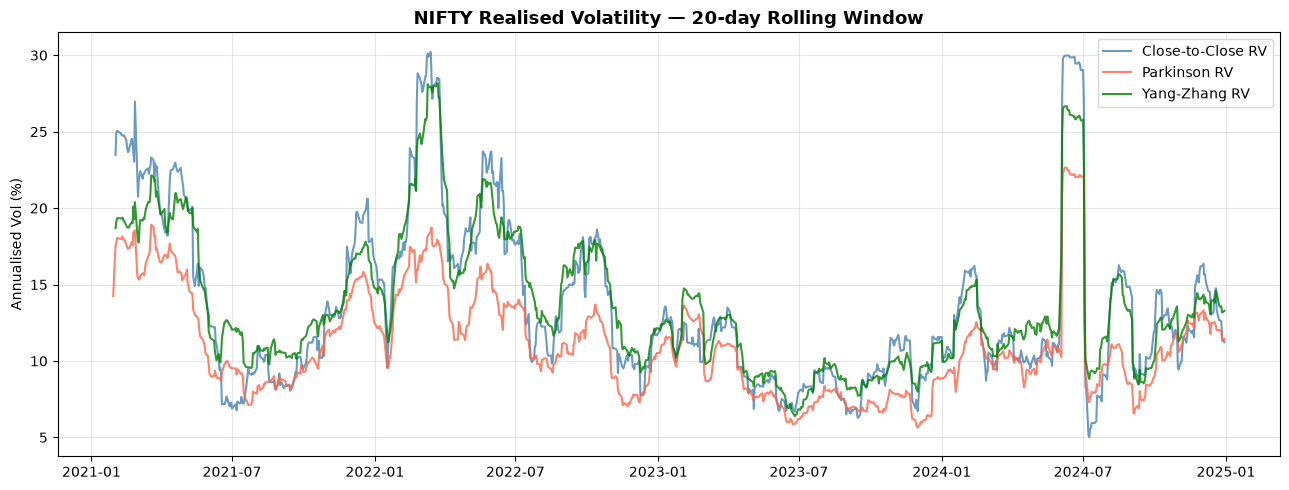

All three estimators track each other closely.
Yang-Zhang is smoothest because it uses the most information per day.


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(rv_ctc.index,  rv_ctc  * 100, color="steelblue",  lw=1.5, alpha=0.8, label="Close-to-Close RV")
ax.plot(rv_park.index, rv_park * 100, color="tomato",      lw=1.5, alpha=0.8, label="Parkinson RV")
ax.plot(rv_yz.index,   rv_yz   * 100, color="green",       lw=1.5, alpha=0.8, label="Yang-Zhang RV")

ax.set_title(f"NIFTY Realised Volatility — {RV_WINDOW}-day Rolling Window", fontsize=13, fontweight="bold")
ax.set_ylabel("Annualised Vol (%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("All three estimators track each other closely.")
print("Yang-Zhang is smoothest because it uses the most information per day.")

---
## 3. IV vs RV — the volatility risk premium

Now we compare India VIX (IV) against our realised vol estimates.

**The hypothesis:**  
If options sellers are compensated for bearing vol risk, then IV > RV on average.  
This is the **volatility risk premium (VRP)** — the excess you earn for being short vol.

We align India VIX (which is forward-looking, 30-day expectation) with 20-day trailing RV.
This is not a perfect alignment, but it is the standard research approach.

In [8]:
# Align VIX with Yang-Zhang RV (our best estimator)
df_combined = pd.DataFrame({
    "iv" : vix,
    "rv" : rv_yz,
}).dropna()

df_combined["spread"] = df_combined["iv"] - df_combined["rv"]
df_combined["iv_above_rv"] = (df_combined["spread"] > 0).astype(int)

pct_iv_above = df_combined["iv_above_rv"].mean() * 100
avg_spread   = df_combined["spread"].mean() * 100
med_spread   = df_combined["spread"].median() * 100

print(f"Period         : {df_combined.index[0].date()} to {df_combined.index[-1].date()}")
print(f"Trading days   : {len(df_combined)}")
print(f"IV > RV        : {pct_iv_above:.1f}% of days")
print(f"Avg IV-RV gap  : {avg_spread:.2f}%")
print(f"Median IV-RV   : {med_spread:.2f}%")
print()
print("This gap is the structural edge of short-vol strategies.")

Period         : 2021-02-01 to 2024-12-30
Trading days   : 955
IV > RV        : 88.8% of days
Avg IV-RV gap  : 2.33%
Median IV-RV   : 2.59%

This gap is the structural edge of short-vol strategies.


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(df_combined.index, df_combined["iv"]  * 100, color="steelblue",  lw=1.8, label="India VIX (IV)")
ax1.plot(df_combined.index, df_combined["rv"]  * 100, color="tomato",     lw=1.8, label="Yang-Zhang RV")
ax1.fill_between(df_combined.index,
                 df_combined["iv"] * 100,
                 df_combined["rv"] * 100,
                 where=(df_combined["iv"] >= df_combined["rv"]),
                 alpha=0.15, color="green", label="IV > RV (vol carry)")
ax1.fill_between(df_combined.index,
                 df_combined["iv"] * 100,
                 df_combined["rv"] * 100,
                 where=(df_combined["iv"] < df_combined["rv"]),
                 alpha=0.15, color="red", label="RV > IV (unfav. regime)")
ax1.set_title("India VIX vs NIFTY Realised Volatility", fontsize=13, fontweight="bold")
ax1.set_ylabel("Volatility (%)")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

spread = df_combined["spread"] * 100
ax2.bar(spread.index, spread,
        color=["steelblue" if x >= 0 else "tomato" for x in spread],
        alpha=0.7, width=1.5)
ax2.axhline(0, color="black", lw=0.9)
ax2.axhline(avg_spread, color="gray", ls="--", lw=1.2, label=f"Avg spread: {avg_spread:.1f}%")
ax2.set_ylabel("IV − RV (%)")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 4. Regime analysis

Not every period is good for selling vol.
High VIX environments (market stress) can be dangerous for short-vol positions.

We define two regimes:
- **Low vol regime**: VIX below its median → favourable for short-vol
- **High vol regime**: VIX above its median → more risk for short-vol sellers

In [ ]:
vix_median = df_combined["iv"].median()
df_combined["regime"] = np.where(df_combined["iv"] > vix_median, "High VIX", "Low VIX")

regime_stats = df_combined.groupby("regime").agg(
    days         = ("spread", "count"),
    avg_spread   = ("spread", "mean"),
    pct_iv_above = ("iv_above_rv", "mean"),
    avg_iv       = ("iv", "mean"),
    avg_rv       = ("rv", "mean"),
).round(4)

regime_stats["avg_spread_%"]   = (regime_stats["avg_spread"] * 100).round(2)
regime_stats["pct_iv_above_%"] = (regime_stats["pct_iv_above"] * 100).round(1)
regime_stats["avg_iv_%"]       = (regime_stats["avg_iv"] * 100).round(2)
regime_stats["avg_rv_%"]       = (regime_stats["avg_rv"] * 100).round(2)

print(f"VIX median (regime split): {vix_median:.2%}")
print()
print(regime_stats[["days", "avg_iv_%", "avg_rv_%", "avg_spread_%", "pct_iv_above_%"]].to_string())
print()
print("Key insight: even in high-VIX regimes, IV typically exceeds RV.")
print("The spread is just smaller and more volatile.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, regime, color in [
    (axes[0], "Low VIX",  "steelblue"),
    (axes[1], "High VIX", "tomato"),
]:
    sub = df_combined[df_combined["regime"] == regime]["spread"] * 100
    ax.hist(sub, bins=40, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(0,           color="black", lw=1.5, label="Zero")
    ax.axvline(sub.mean(),  color="gold",  lw=2,   ls="--", label=f"Mean: {sub.mean():.1f}%")
    ax.set_title(f"IV−RV Spread Distribution — {regime}", fontweight="bold")
    ax.set_xlabel("IV − RV (%)"); ax.set_ylabel("Days")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Volatility Risk Premium by Regime", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---
## 5. Rolling VIX percentile — a regime filter for the backtest

The backtest in Notebook 04 will use a rolling VIX percentile to optionally filter out
high-risk entries. High percentile = elevated vol = tighter stops or skip the trade.

In [ ]:
PERCENTILE_WINDOW = 252  # 1 year rolling

vix_pct = df_combined["iv"].rolling(PERCENTILE_WINDOW).rank(pct=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(df_combined.index, df_combined["iv"] * 100, color="darkorange", lw=1.5)
ax1.set_title("India VIX", fontweight="bold"); ax1.set_ylabel("VIX (%)")
ax1.grid(alpha=0.3)

ax2.plot(vix_pct.index, vix_pct * 100, color="steelblue", lw=1.5)
ax2.axhline(80, color="red",  ls="--", lw=1.2, label="80th pct — danger zone")
ax2.axhline(20, color="green",ls="--", lw=1.2, label="20th pct — low vol")
ax2.set_title("Rolling 1-year VIX Percentile", fontweight="bold")
ax2.set_ylabel("Percentile"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Save for backtest notebook
vix_pct.rename("vix_percentile").to_csv("../data/processed/vix_percentile.csv")
df_combined.to_csv("../data/processed/iv_rv_combined.csv")
print("Saved iv_rv_combined.csv and vix_percentile.csv")

---
## 6. NSE Bhavcopy data loader — demo

When you have real NSE F&O bhavcopy files, this is how you load them.
The cell below shows the pipeline — it will error if you have no files in data/raw/ yet.
That is expected. We will use this in Notebook 04 once you download the files.

To get bhavcopy files:
1. Go to https://www.nseindia.com/market-data/future-and-options-bhavcopy-report
2. Download a few months of NIFTY files into `data/raw/`
3. Run the cell below

In [9]:
import os
from data_loader import (
    load_bhavcopy_folder, filter_nifty_options,
    add_time_to_expiry, join_spot, data_quality_report
)

raw_folder = "../data/raw"
files = [f for f in os.listdir(raw_folder) if f.endswith(".csv")] if os.path.exists(raw_folder) else []

if not files:
    print("No bhavcopy files found in data/raw/ yet.")
    print("Download files from NSE and re-run this cell.")
    print()
    print("Expected pipeline:")
    print("  df = load_bhavcopy_folder('data/raw/')")
    print("  df = filter_nifty_options(df)")
    print("  df = add_time_to_expiry(df)")
    print("  df = join_spot(df, nifty['close'])")
    print("  df.to_csv('data/processed/nifty_options.csv', index=False)")
else:
    print(f"Found {len(files)} files. Loading...")
    df = load_bhavcopy_folder(raw_folder)
    df = filter_nifty_options(df)
    df = add_time_to_expiry(df)

    spot_series = nifty["close"].rename("spot")
    df = join_spot(df, spot_series)
    df.to_csv("../data/processed/nifty_options.csv", index=False)

    print("Loaded and saved nifty_options.csv")
    print()
    rpt = data_quality_report(df)
    for k, v in rpt.items():
        print(f"  {k}: {v}")

Found 120 files. Loading...
Loaded and saved nifty_options.csv

  total_rows: 156582
  date_range: (Timestamp('2024-01-05 00:00:00'), Timestamp('2024-06-28 00:00:00'))
  unique_dates: 116
  unique_expiries: 43
  unique_strikes: 181
  option_types: {'PE': 78820, 'CE': 77762}
  missing_close: 0
  zero_price_rows: 0


---
## Key takeaways

1. **IV > RV on most days** — the volatility risk premium is real and persistent in NIFTY.
2. **India VIX** is a reliable IV proxy — it is computed from actual NIFTY option prices by NSE.
3. **Yang-Zhang** is the most accurate RV estimator — use it as the primary benchmark.
4. **Regime matters** — high-VIX periods have higher spreads but also higher variance. Position sizing matters.
5. **Rolling VIX percentile** is a useful regime filter for the backtest.

This analysis provides the theoretical foundation for the short-straddle backtest:
> *If IV consistently exceeds RV, selling options should be profitable on average.*

**Next:** Notebook 04 — Strategy Backtest: does this edge hold after costs and drawdowns?